# Fundamentals Alpha — Which Fundamentals Predict Future Returns?

**Goal:** Identify which fundamental characteristics (valuation, quality, profitability) predict
forward stock returns over 6-month, 1-year, 2-year, 3-year, and 5-year horizons.

**Data:** `monthly_pe` table — 296K rows, 1,414 tickers, 1999–2026 (monthly snapshots of
fundamental ratios and price). Sector assignments from `company_overview`.

**Features (54):**
- Valuation level: PE, P/FCF, EV/EBITDA, P/S, P/BV, P/TBV, FCF yield, dividend yield
- Yield metrics: earnings yield, FCF yield, EBITDA/EV yield — current, 3yr avg, 5yr avg
- Normalized multiples: CAPE-style 5yr normalized PE, P/FCF, EV/EBITDA, P/S
- Mean-reversion signals: ratio ÷ own 5yr rolling median (>1 = trading at premium)
- Quality / profitability: ROA, ROE, ROIC + their 5yr-rolling premiums
- Growth: trailing 1yr / 3yr / 5yr CAGRs for revenue, earnings, and FCF
- Sector-relative: ratio ÷ sector median for that month (removes sector-level base rate)

**Approach** (mirrors `ibd50_analysis.ipynb`):
1. Compute forward returns from monthly price data
2. EDA — correlation heatmap, quintile return analysis, factor IC
3. XGBoost + SHAP — which features drive returns and in which direction
4. Walk-forward validation — honest out-of-sample performance
5. Live scoring — rank all current tickers by predicted return

---
## Cell 1 — Imports & Config

In [1]:
import sys, warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from dotenv import load_dotenv
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', None)

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
load_dotenv(ROOT / '.env', override=True)

from historic_fundamentals import get_pe_stats
from historic_fundamentals.db import HistoricFundamentalsDB

DB_PATH        = os.getenv('HF_DB_PATH', str(ROOT / 'data' / 'historic_fundamentals.duckdb'))
PRICES_DB_PATH = os.getenv('PRICES_DB_PATH', '')

# ── Return horizons: name -> months ahead ─────────────────────────────────────
RETURN_HORIZONS = {
    'ret_6m':  6,
    'ret_1y':  12,
    'ret_2y':  24,
    'ret_3y':  36,
    'ret_5y':  60,
}
RETURN_COLS    = list(RETURN_HORIZONS.keys())
PRIMARY_TARGET = 'ret_1y'   # 1-year horizon is the natural fit for fundamental investing

MIN_VALID            = 200   # minimum rows for a horizon to enter analysis
N_BINS               = 5     # quintiles for EDA
RANDOM_STATE         = 42
WINSOR_CLIP          = 3.0   # clip returns beyond ±300% (survivorship extremes)
SHAP_PRUNE_THRESHOLD = 0.05  # drop features with mean |SHAP| < 5% of top feature score

print('Imports done.')
print('DB:', DB_PATH)
print('Prices DB:', PRICES_DB_PATH or '(not set)')

Imports done.
DB: /home/pedro/projects/fin_import2/data/historic_fundamentals.duckdb
Prices DB: /home/pedro/projects/trade_systems/data/prices.duckdb


---
## Cell 2 — Load monthly_pe Data

In [2]:
conn = duckdb.connect(DB_PATH, read_only=True)
raw  = conn.execute("""
    SELECT ticker, month_end_date, price,
           ttm_revenue, ttm_eps, ttm_fcf,
           pe_ratio,    pe_rolling_5yr_median,
           earnings_yield, earnings_yield_3y_avg, earnings_yield_5y_avg,
           normalized_pe_5y,
           pfcf_ratio,  pfcf_rolling_5yr_median, fcf_yield,
           fcf_yield_3y_avg, fcf_yield_5y_avg, normalized_pfcf_5y,
           ev_ebitda,   ev_ebitda_rolling_5yr_median,
           ebitda_ev_yield, ebitda_ev_yield_3y_avg, ebitda_ev_yield_5y_avg,
           normalized_evebitda_5y,
           ps_ratio,    ps_rolling_5yr_median,    normalized_ps_5y,
           roa,         roa_rolling_5yr_median,
           roe,         roe_rolling_5yr_median,
           roic,        roic_rolling_5yr_median,
           pbv,         pbv_rolling_5yr_median,
           ptbv,        ptbv_rolling_5yr_median,
           dividend_yield,
           ttm_gross_margin,     gross_margin_5y_median,     gross_margin_slope_5y,
           ttm_operating_margin, operating_margin_5y_median,
           operating_margin_change_3y, operating_margin_slope_5y,
           ttm_fcf_margin, fcf_margin_5y_median, fcf_margin_change_3y,
           roa_stability_5y, debt_to_ebitda, interest_coverage
    FROM monthly_pe
    WHERE price > 0
    ORDER BY ticker, month_end_date
""").df()
conn.close()

raw['month_end_date'] = pd.to_datetime(raw['month_end_date'])

print(f'Rows: {len(raw):,}  |  Tickers: {raw["ticker"].nunique():,}')
print(f'Date range: {raw["month_end_date"].min().date()} → {raw["month_end_date"].max().date()}')
raw.head(3)

Rows: 296,348  |  Tickers: 1,414
Date range: 1999-12-31 → 2026-05-31


,ticker,month_end_date,price,ttm_revenue,ttm_eps,ttm_fcf,pe_ratio,pe_rolling_5yr_median,earnings_yield,earnings_yield_3y_avg,earnings_yield_5y_avg,normalized_pe_5y,pfcf_ratio,pfcf_rolling_5yr_median,fcf_yield,fcf_yield_3y_avg,fcf_yield_5y_avg,normalized_pfcf_5y,ev_ebitda,ev_ebitda_rolling_5yr_median,ebitda_ev_yield,ebitda_ev_yield_3y_avg,ebitda_ev_yield_5y_avg,normalized_evebitda_5y,ps_ratio,ps_rolling_5yr_median,normalized_ps_5y,roa,roa_rolling_5yr_median,roe,roe_rolling_5yr_median,roic,roic_rolling_5yr_median,pbv,pbv_rolling_5yr_median,ptbv,ptbv_rolling_5yr_median,dividend_yield,ttm_gross_margin,gross_margin_5y_median,gross_margin_slope_5y,ttm_operating_margin,operating_margin_5y_median,operating_margin_change_3y,operating_margin_slope_5y,ttm_fcf_margin,fcf_margin_5y_median,fcf_margin_change_3y,roa_stability_5y,debt_to_ebitda,interest_coverage
0,A,2006-10-31,22.747,4973000000.000,7.911,449000000.000,2.875,NaN,0.348,NaN,NaN,NaN,21.177,NaN,0.047,NaN,NaN,NaN,13.946,NaN,0.072,NaN,NaN,NaN,1.912,NaN,NaN,0.449,NaN,0.907,NaN,0.202,NaN,2.606,NaN,2.990,NaN,NaN,0.534,NaN,NaN,0.093,NaN,NaN,NaN,0.090,NaN,NaN,NaN,0.248,0.115
1,A,2006-11-30,20.345,4973000000.000,7.911,449000000.000,2.572,NaN,0.389,NaN,NaN,NaN,18.940,NaN,0.053,NaN,NaN,NaN,12.047,NaN,0.083,NaN,NaN,NaN,1.710,NaN,NaN,0.449,NaN,0.907,NaN,0.202,NaN,2.331,NaN,2.674,NaN,NaN,0.534,NaN,NaN,0.093,NaN,NaN,NaN,0.090,NaN,NaN,NaN,0.248,0.115
2,A,2006-12-31,22.268,4973000000.000,7.911,449000000.000,2.815,NaN,0.355,NaN,NaN,NaN,20.730,NaN,0.048,NaN,NaN,NaN,13.567,NaN,0.074,NaN,NaN,NaN,1.872,NaN,NaN,0.449,NaN,0.907,NaN,0.202,NaN,2.552,NaN,2.927,NaN,NaN,0.534,NaN,NaN,0.093,NaN,NaN,NaN,0.090,NaN,NaN,NaN,0.248,0.115


---
## Cell 2b — Sector / Industry Assignments

Join the latest `company_overview` sector and industry into `raw` by ticker.
Sector assignments are applied uniformly across all historical months (standard
factor convention — we use today's GICS-equivalent classification throughout history).

In [3]:
# ── Load sector / industry from company_overview ─────────────────────────────
AV_PATH = os.getenv('AV_DB_PATH', str(ROOT / 'data' / 'av_financials.duckdb'))
if not Path(AV_PATH).is_absolute():
    AV_PATH = str(ROOT / AV_PATH)
try:
    av_conn = duckdb.connect(AV_PATH, read_only=True)
    sector_map = av_conn.execute("""
        SELECT ticker, sector, industry
        FROM (
            SELECT ticker, sector, industry,
                   ROW_NUMBER() OVER (PARTITION BY ticker ORDER BY fetch_date DESC) AS rn
            FROM company_overview
            WHERE sector IS NOT NULL AND sector NOT IN ('None', '', 'N/A')
        ) t WHERE rn = 1
    """).df()
    av_conn.close()
except Exception as e:
    sector_map = pd.DataFrame(columns=['ticker', 'sector', 'industry'])
    print(f'Sector assignments unavailable: {e}')

raw = raw.merge(sector_map, on='ticker', how='left')
n_with = raw['sector'].notna().sum()
print(f'Sector assigned: {n_with:,} / {len(raw):,} rows ({n_with/len(raw):.0%})')
print(f'Unique sectors:   {raw["sector"].nunique()}')
print(f'Unique industries:{raw["industry"].nunique()}')
raw[['ticker','sector','industry']].drop_duplicates('ticker').groupby('sector').size().sort_values(ascending=False)

Sector assigned: 296,348 / 296,348 rows (100%)
Unique sectors:   11
Unique industries:139


sector
FINANCIAL SERVICES        229
INDUSTRIALS               228
TECHNOLOGY                202
CONSUMER CYCLICAL         173
HEALTHCARE                170
REAL ESTATE                97
BASIC MATERIALS            85
CONSUMER DEFENSIVE         70
ENERGY                     63
UTILITIES                  55
COMMUNICATION SERVICES     42
dtype: int64

---
## Cell 3 — Compute Forward Returns

For each (ticker, month T), the forward return at horizon N is:

    ret_N = price[T + N months] / price[T] - 1

We look for a price within ±45 days of the target date. Rows where the future price
is not yet available (too recent) will be NaN — handled in Cell 5.

In [4]:
def compute_forward_returns(df, horizons, tolerance_days=45):
    """
    Add forward return columns using a vectorized merge approach.
    For each row, find the closest future price within tolerance_days of target date.
    """
    df = df.sort_values(['ticker', 'month_end_date']).reset_index(drop=True).copy()

    for col, months in horizons.items():
        # Build a "target date" column
        df['_target'] = df['month_end_date'] + pd.DateOffset(months=months)

        # Self-join on ticker, find all price rows within ±tolerance of target
        left  = df[['ticker', 'month_end_date', 'price', '_target']].copy()
        right = df[['ticker', 'month_end_date', 'price']].rename(
            columns={'month_end_date': 'future_date', 'price': 'future_price'})

        merged = left.merge(right, on='ticker', how='left')
        merged['day_diff'] = (merged['future_date'] - merged['_target']).abs().dt.days
        merged = merged[merged['day_diff'] <= tolerance_days]

        # Keep closest future date per (ticker, month_end_date)
        merged = (merged
                  .sort_values('day_diff')
                  .groupby(['ticker', 'month_end_date'], sort=False)
                  .first()
                  .reset_index()[['ticker', 'month_end_date', 'future_price']])

        df = df.merge(merged, on=['ticker', 'month_end_date'], how='left')
        df[col] = df['future_price'] / df['price'] - 1
        df = df.drop(columns=['future_price', '_target'])

        valid = df[col].notna().sum()
        print(f'  {col}: {valid:,} valid  '
              f'mean={df.loc[df[col].notna(), col].mean()*100:.1f}%  '
              f'median={df.loc[df[col].notna(), col].median()*100:.1f}%')

    return df

print('Computing forward returns...')
df = compute_forward_returns(raw, RETURN_HORIZONS)

# Winsorise: clip extreme returns (bankrupt / delisted / splits)
for col in RETURN_COLS:
    df[col] = df[col].clip(-WINSOR_CLIP, WINSOR_CLIP)

print(f'\nDone. Total rows: {len(df):,}')

Computing forward returns...
  ret_6m: 289,273 valid  mean=9.9%  median=5.7%
  ret_1y: 280,797 valid  mean=19.2%  median=10.9%
  ret_2y: 263,894 valid  mean=40.5%  median=22.4%
  ret_3y: 247,136 valid  mean=62.2%  median=36.4%
  ret_5y: 213,896 valid  mean=118.1%  median=68.9%

Done. Total rows: 296,348


---
## Cell 3b — Growth Features (Trailing CAGRs)

For each (ticker, month T) compute the trailing growth rates over 1, 3, and 5 years
from the **same month, N years earlier** of `ttm_revenue`, `ttm_eps`, and `ttm_fcf`.
These are backward-looking — no look-ahead bias.

- `rev_cagr_3y = (ttm_revenue_T / ttm_revenue_{T-36mo})^(1/3) - 1`
- Negative bases (loss-making years) produce NaN — handled by feature imputation later

This uses the same self-join pattern as the forward-return computation, but with
a `-N months` offset.

In [5]:
GROWTH_SPECS = {
    'rev':  ('ttm_revenue', [1, 3, 5]),
    'earn': ('ttm_eps',     [1, 3, 5]),
    'fcf':  ('ttm_fcf',     [1, 3, 5]),
}

def add_trailing_cagr(df, base_col, years, prefix, tolerance_days=45):
    """
    For each row, look up base_col from `years` ago (within tolerance_days) and
    compute the annualized growth rate. Both base values must be positive — negative
    bases (loss-making) yield NaN.
    """
    out_col = f'{prefix}_cagr_{years}y'
    months  = years * 12

    df = df.copy()
    df['_target'] = df['month_end_date'] - pd.DateOffset(months=months)

    left  = df[['ticker', 'month_end_date', '_target', base_col]].copy()
    right = df[['ticker', 'month_end_date', base_col]].rename(
        columns={'month_end_date': 'past_date', base_col: f'past_{base_col}'})

    merged = left.merge(right, on='ticker', how='left')
    merged['day_diff'] = (merged['past_date'] - merged['_target']).abs().dt.days
    merged = merged[merged['day_diff'] <= tolerance_days]
    merged = (merged
              .sort_values('day_diff')
              .groupby(['ticker', 'month_end_date'], sort=False)
              .first()
              .reset_index()[['ticker', 'month_end_date', f'past_{base_col}']])

    out = df.merge(merged, on=['ticker', 'month_end_date'], how='left')
    base_now = out[base_col]
    base_past = out[f'past_{base_col}']

    # Both values must be positive for CAGR to make sense
    valid = (base_now > 0) & (base_past > 0)
    cagr = np.where(valid, (base_now / base_past) ** (1 / years) - 1, np.nan)

    out[out_col] = pd.Series(cagr).clip(-1.0, 5.0).values  # cap at -100% / +500%
    out = out.drop(columns=[f'past_{base_col}', '_target'])
    return out, out_col

print('Computing trailing CAGRs...')
growth_cols = []
for prefix, (base_col, year_list) in GROWTH_SPECS.items():
    for years in year_list:
        df, col = add_trailing_cagr(df, base_col, years, prefix)
        growth_cols.append(col)
        n_valid = df[col].notna().sum()
        print(f'  {col:20}: {n_valid:>7,} valid  '
              f'median={df.loc[df[col].notna(), col].median()*100:+.1f}%/y')

print(f'\nAdded {len(growth_cols)} growth features.')

Computing trailing CAGRs...
  rev_cagr_1y         : 277,935 valid  median=+6.1%/y
  rev_cagr_3y         : 244,752 valid  median=+6.0%/y
  rev_cagr_5y         : 212,138 valid  median=+6.1%/y
  earn_cagr_1y        : 223,245 valid  median=+9.9%/y
  earn_cagr_3y        : 193,137 valid  median=+8.4%/y
  earn_cagr_5y        : 167,039 valid  median=+8.2%/y
  fcf_cagr_1y         : 204,087 valid  median=+8.6%/y
  fcf_cagr_3y         : 175,563 valid  median=+8.5%/y
  fcf_cagr_5y         : 151,484 valid  median=+8.5%/y

Added 9 growth features.


---
## Cell 4 — Feature Engineering

Four feature groups:
- **Valuation level** — absolute multiples (PE, P/FCF, EV/EBITDA, P/S, P/BV, P/TBV, FCF yield)
- **Mean-reversion signal** — current multiple ÷ own 5yr rolling median (>1 = premium, <1 = discount)
- **Quality / profitability** — ROA, ROE, ROIC + their 5yr-rolling premiums
- **Sector-relative** — current multiple ÷ sector median for that same month. Values >1 mean the
  stock trades at a premium to its sector peers. This removes the sector-level base rate so the
  model learns "is PE high *for this sector*?" rather than "is PE high absolutely?"

In [6]:
def safe_ratio(a, b, clip=10.0):
    """a / b, clipped to avoid extreme values from near-zero denominators."""
    return (a / b.replace(0, np.nan)).clip(-clip, clip)

# ── Mean-reversion premiums ───────────────────────────────────────────────────
df["pe_premium"]   = safe_ratio(df["pe_ratio"],   df["pe_rolling_5yr_median"])
df["pfcf_premium"] = safe_ratio(df["pfcf_ratio"], df["pfcf_rolling_5yr_median"])
df["ev_premium"]   = safe_ratio(df["ev_ebitda"],  df["ev_ebitda_rolling_5yr_median"])
df["ps_premium"]   = safe_ratio(df["ps_ratio"],   df["ps_rolling_5yr_median"])
df["roa_premium"]  = safe_ratio(df["roa"],        df["roa_rolling_5yr_median"])
df["roe_premium"]  = safe_ratio(df["roe"],        df["roe_rolling_5yr_median"])
df["roic_premium"] = safe_ratio(df["roic"],       df["roic_rolling_5yr_median"])
df["pbv_premium"]  = safe_ratio(df["pbv"],        df["pbv_rolling_5yr_median"])
df["ptbv_premium"] = safe_ratio(df["ptbv"],       df["ptbv_rolling_5yr_median"])

# NOTE: goal_discount / goal_upside excluded — look-ahead bias via pe_lt_median.

# ── Sector-relative valuation ─────────────────────────────────────────────────
# For each (ticker, month): metric / sector_median_for_that_month.
# Only positive values enter the sector median for ratio metrics.
_SEC_REL = [
    ("pe_ratio",   True,  "pe_sector_rel"),
    ("pfcf_ratio", True,  "pfcf_sector_rel"),
    ("ev_ebitda",  True,  "ev_sector_rel"),
    ("ps_ratio",   True,  "ps_sector_rel"),
    ("roic",       False, "roic_sector_rel"),
    ("roa",        False, "roa_sector_rel"),
]

if "sector" in df.columns and df["sector"].notna().any():
    for src_col, positive_only, out_col in _SEC_REL:
        mask = df["sector"].notna() & df[src_col].notna()
        if positive_only:
            mask = mask & (df[src_col] > 0)
        med = (
            df[mask]
            .groupby(["sector", "month_end_date"])[src_col]
            .median()
            .rename("_med")
            .reset_index()
        )
        tmp = df[["sector", "month_end_date", src_col]].merge(
            med, on=["sector", "month_end_date"], how="left"
        )
        df[out_col] = safe_ratio(
            pd.Series(tmp[src_col].values, index=df.index),
            pd.Series(tmp["_med"].values,  index=df.index),
        )
    sector_rel_cols = [c for _, _, c in _SEC_REL]
    cov = df[sector_rel_cols].notna().mean().mean()
    print(f"Sector-relative features: {len(sector_rel_cols)} cols, avg coverage {cov:.0%}")
else:
    sector_rel_cols = []
    print("Sector column not available — sector-relative features skipped")

FEATURE_COLS = [
    # Valuation level
    "pe_ratio", "pfcf_ratio", "ev_ebitda", "ps_ratio", "pbv", "ptbv",
    "fcf_yield", "dividend_yield",
    # Yield metrics (sign-preserving; negative = loss-making)
    "earnings_yield", "earnings_yield_3y_avg", "earnings_yield_5y_avg",
    "fcf_yield_3y_avg", "fcf_yield_5y_avg",
    "ebitda_ev_yield", "ebitda_ev_yield_3y_avg", "ebitda_ev_yield_5y_avg",
    # Normalized / CAPE-style multiples
    "normalized_pe_5y", "normalized_pfcf_5y", "normalized_evebitda_5y", "normalized_ps_5y",
    # Mean-reversion signals (5yr rolling median)
    "pe_premium", "pfcf_premium", "ev_premium", "ps_premium",
    "pbv_premium", "ptbv_premium",
    # Quality / profitability
    "roa", "roe", "roic",
    "roa_premium", "roe_premium", "roic_premium",
    # Historical medians (5yr rolling)
    "pe_rolling_5yr_median", "pfcf_rolling_5yr_median", "ev_ebitda_rolling_5yr_median",
    "ps_rolling_5yr_median", "roa_rolling_5yr_median", "roe_rolling_5yr_median",
    "roic_rolling_5yr_median",
    # Growth (trailing CAGRs — backward-looking, no leakage)
    "rev_cagr_1y",  "rev_cagr_3y",  "rev_cagr_5y",
    "earn_cagr_1y", "earn_cagr_3y", "earn_cagr_5y",
    "fcf_cagr_1y",  "fcf_cagr_3y",  "fcf_cagr_5y",
    # Margins — level, trend, and leverage
    "ttm_gross_margin", "gross_margin_5y_median", "gross_margin_slope_5y",
    "ttm_operating_margin", "operating_margin_5y_median",
    "operating_margin_change_3y", "operating_margin_slope_5y",
    "ttm_fcf_margin", "fcf_margin_5y_median", "fcf_margin_change_3y",
    "roa_stability_5y", "debt_to_ebitda", "interest_coverage",
    # Sector-relative (current multiple / sector median for that month)
] + sector_rel_cols

print(f"Features: {len(FEATURE_COLS)}")
print()
print("Feature coverage (fraction non-null, full dataset):")
coverage = df[FEATURE_COLS].notna().mean().sort_values(ascending=False)
for feat, pct in coverage.items():
    print(f"  {feat:35}: {pct:.0%}")

Sector-relative features: 6 cols, avg coverage 90%
Features: 67

Feature coverage (fraction non-null, full dataset):
  earnings_yield                     : 99%
  roa                                : 99%
  roa_sector_rel                     : 99%
  fcf_yield                          : 99%
  ttm_operating_margin               : 99%
  ps_ratio                           : 99%
  ps_sector_rel                      : 99%
  ttm_gross_margin                   : 99%
  ttm_fcf_margin                     : 99%
  pbv                                : 97%
  roe                                : 97%
  interest_coverage                  : 96%
  roic                               : 94%
  roic_sector_rel                    : 94%
  rev_cagr_1y                        : 94%
  ebitda_ev_yield                    : 91%
  earnings_yield_3y_avg              : 89%
  fcf_yield_3y_avg                   : 89%
  debt_to_ebitda                     : 87%
  pe_ratio                           : 86%
  pe_sector_rel        

---
## Cell 5 — Return Target Masking

NaN forward returns mean the future price is not yet available (too recent to have N-month data).
We build a boolean mask per horizon and derive `EDA_TARGETS` automatically.

In [7]:
for col in RETURN_COLS:
    df[col + '_valid'] = df[col].notna()

def get_valid(data, return_col):
    return data[data[return_col + '_valid']].copy()

valid_summary = pd.DataFrame({
    'valid_rows': [df[c + '_valid'].sum() for c in RETURN_COLS],
    'valid_pct':  [df[c + '_valid'].mean() * 100 for c in RETURN_COLS],
    'mean_ret':   [df.loc[df[c + '_valid'], c].mean() * 100 for c in RETURN_COLS],
    'median_ret': [df.loc[df[c + '_valid'], c].median() * 100 for c in RETURN_COLS],
}, index=RETURN_COLS).round(1)

print('Forward return availability and summary:')
print(valid_summary.to_string())

EDA_TARGETS      = [c for c in RETURN_COLS if df[c + '_valid'].sum() >= MIN_VALID]
ML_TARGETS       = EDA_TARGETS
PRIMARY_ML_TARGET = PRIMARY_TARGET if PRIMARY_TARGET in EDA_TARGETS else EDA_TARGETS[0]

print(f'\nEDA / ML targets: {EDA_TARGETS}')
print(f'Primary ML target: {PRIMARY_ML_TARGET}')

Forward return availability and summary:
        valid_rows  valid_pct  mean_ret  median_ret
ret_6m      289273     97.600     8.200       5.700
ret_1y      280797     94.800    16.200      10.900
ret_2y      263894     89.000    32.500      22.400
ret_3y      247136     83.400    49.800      36.400
ret_5y      213896     72.200    88.500      68.900

EDA / ML targets: ['ret_6m', 'ret_1y', 'ret_2y', 'ret_3y', 'ret_5y']
Primary ML target: ret_1y


---
## Cell 6 — EDA: Feature Correlation Heatmap

Pearson correlation of each feature with each return horizon.
Green = positive predictor of returns, red = negative.

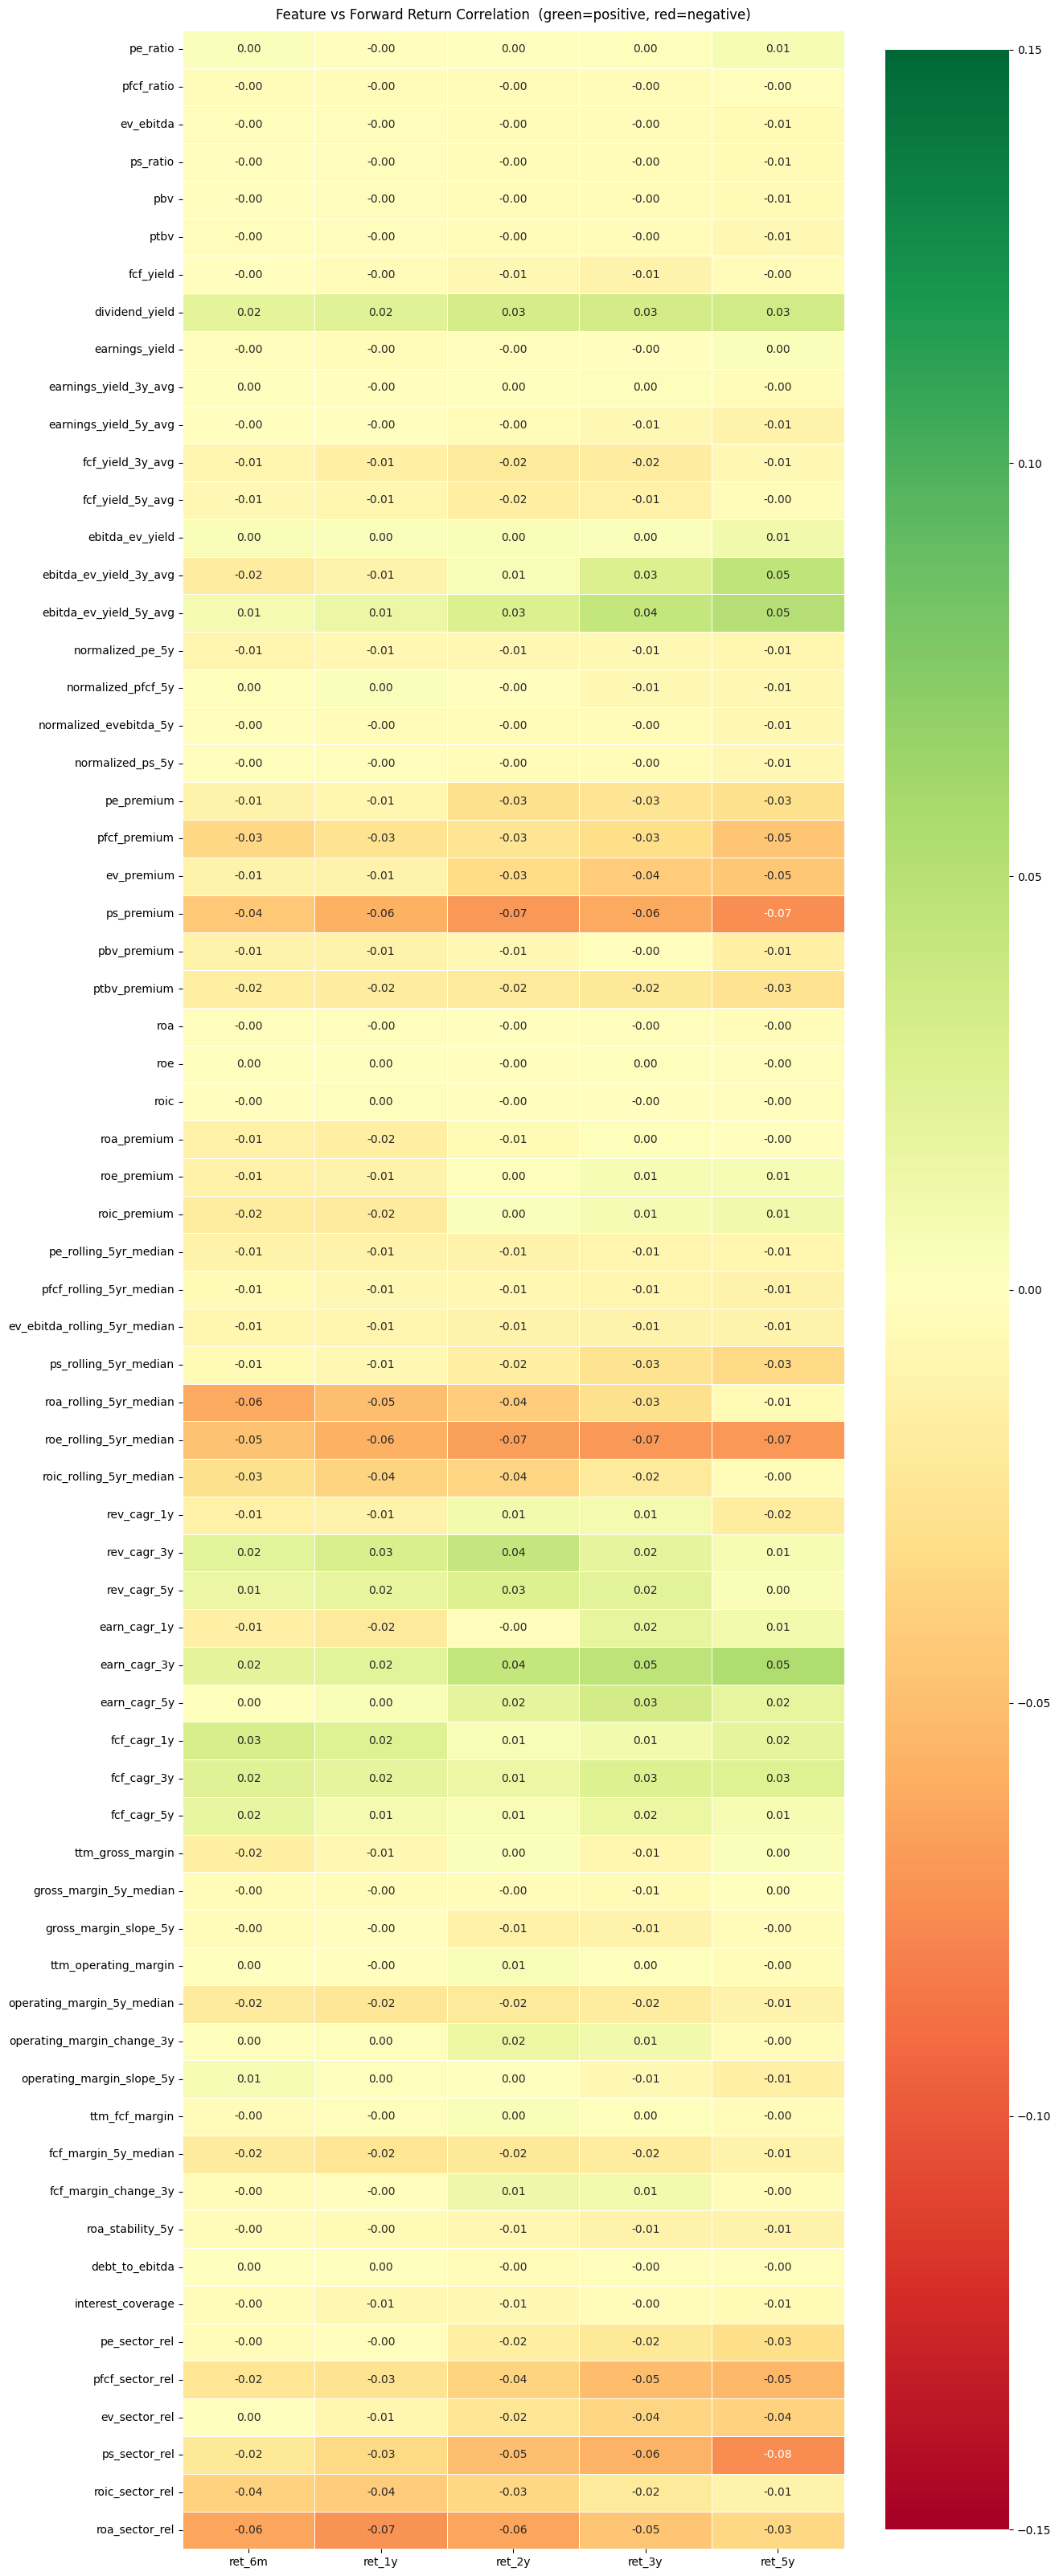

Top features by |correlation| with ret_1y:
roa_sector_rel                 0.072
roe_rolling_5yr_median         0.058
ps_premium                     0.058
roa_rolling_5yr_median         0.050
roic_sector_rel                0.041
roic_rolling_5yr_median        0.037
ps_sector_rel                  0.034
rev_cagr_3y                    0.030
pfcf_sector_rel                0.027
pfcf_premium                   0.027
fcf_cagr_1y                    0.025
dividend_yield                 0.025
fcf_margin_5y_median           0.023
operating_margin_5y_median     0.023
earn_cagr_3y                   0.022
earn_cagr_1y                   0.020
roic_premium                   0.020
fcf_cagr_3y                    0.019
rev_cagr_5y                    0.018
ptbv_premium                   0.017
roa_premium                    0.016
ebitda_ev_yield_5y_avg         0.014
fcf_yield_3y_avg               0.014
pe_rolling_5yr_median          0.013
ev_premium                     0.012
rev_cagr_1y                    0

In [8]:
df_valid_primary = get_valid(df, PRIMARY_ML_TARGET)

corr_targets = [c for c in RETURN_COLS if df[c + '_valid'].sum() >= MIN_VALID]
corr_matrix  = (
    df_valid_primary[FEATURE_COLS + corr_targets]
    .corr()[corr_targets]
    .loc[FEATURE_COLS]
)

fig, ax = plt.subplots(figsize=(len(corr_targets) * 2 + 3, len(FEATURE_COLS) * 0.45 + 2))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', center=0,
    cmap='RdYlGn', linewidths=0.4, ax=ax,
    vmin=-0.15, vmax=0.15
)
ax.set_title('Feature vs Forward Return Correlation  (green=positive, red=negative)',
             fontsize=12, pad=10)
plt.tight_layout()
plt.show()

print(f'Top features by |correlation| with {PRIMARY_ML_TARGET}:')
top = corr_matrix[PRIMARY_ML_TARGET].abs().sort_values(ascending=False)
print(top.round(3).to_string())

---
## Cell 7 — EDA: Factor IC (Information Coefficient)

The Information Coefficient (IC) measures how well a feature ranks stocks in order of their
subsequent returns. Computed as the **monthly cross-sectional Spearman rank correlation**
between each feature and the forward return.

- IC > 0 means higher feature value → higher return
- ICIR = mean(IC) / std(IC) — analogous to Sharpe ratio for a factor
- Rule of thumb: |ICIR| > 0.5 is practically significant

Computing monthly IC (this may take ~1-2 minutes)...

Mean monthly IC by feature and horizon (Spearman):
target                        ret_6m  ret_1y  ret_2y  ret_3y  ret_5y
feature                                                             
normalized_ps_5y              -0.048  -0.065  -0.092  -0.109  -0.121
ps_ratio                      -0.050  -0.066  -0.094  -0.102  -0.116
ps_sector_rel                 -0.043  -0.057  -0.080  -0.087  -0.097
ps_rolling_5yr_median         -0.039  -0.052  -0.077  -0.095  -0.095
pfcf_sector_rel               -0.049  -0.055  -0.068  -0.076  -0.079
pfcf_ratio                    -0.047  -0.052  -0.066  -0.073  -0.074
fcf_yield                      0.046   0.051   0.064   0.073   0.078
normalized_pfcf_5y            -0.036  -0.046  -0.068  -0.073  -0.073
ev_sector_rel                 -0.038  -0.047  -0.067  -0.074  -0.068
fcf_yield_5y_avg               0.032   0.043   0.065   0.077   0.069
ev_ebitda                     -0.038  -0.045  -0.066  -0.070  -0.06

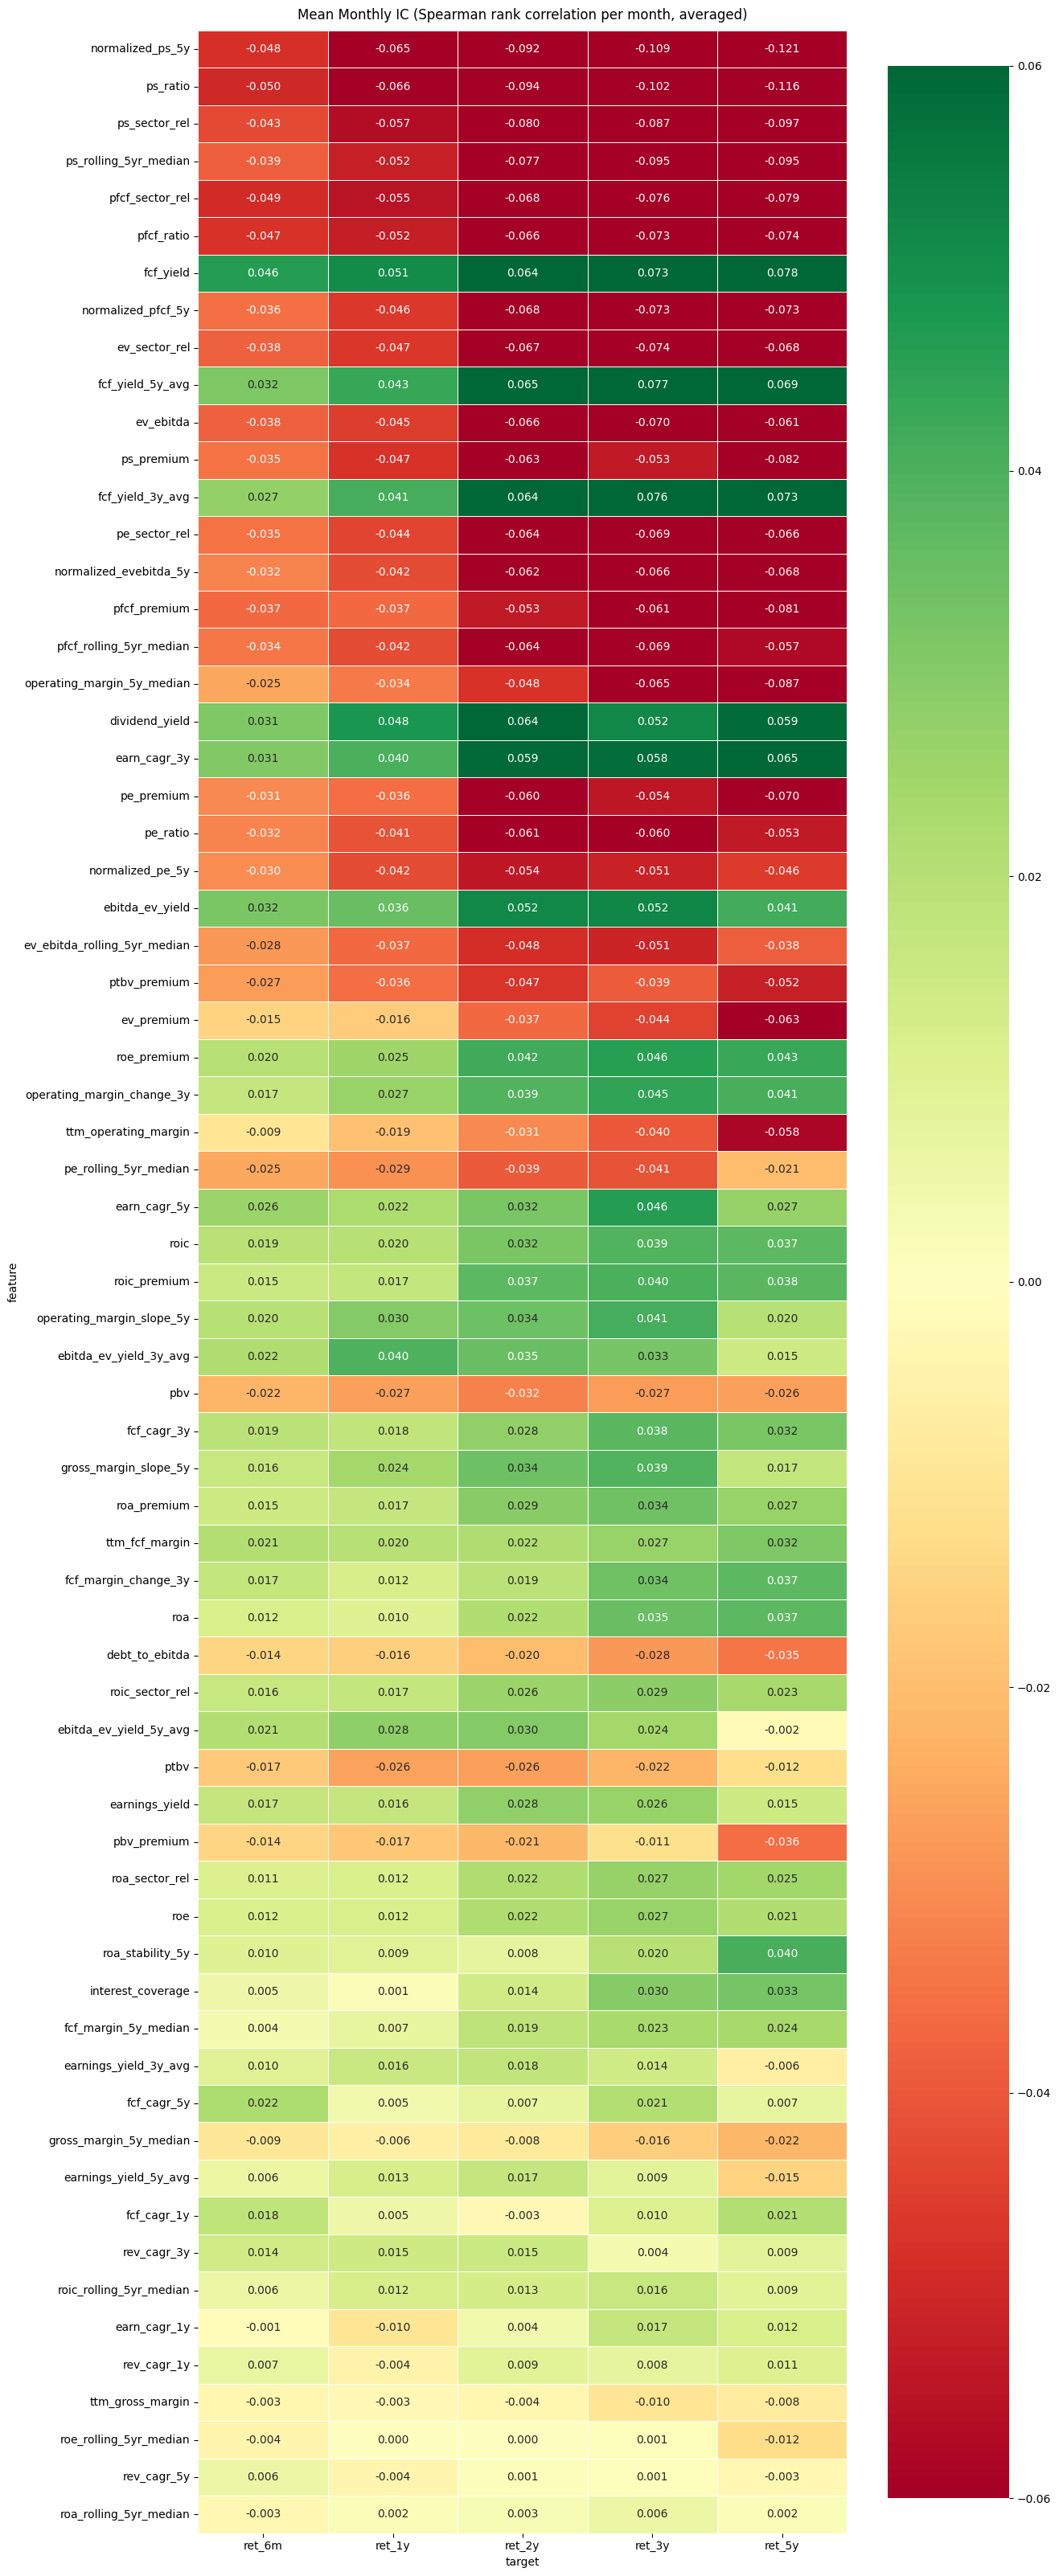


ICIR for ret_1y (|ICIR|>0.5 = practically significant):
feature
pfcf_sector_rel                -0.700
fcf_yield                       0.663
fcf_yield_5y_avg                0.605
pe_sector_rel                  -0.599
ps_ratio                       -0.549
ev_sector_rel                  -0.547
normalized_ps_5y               -0.543
ps_sector_rel                  -0.542
ps_rolling_5yr_median          -0.523
operating_margin_slope_5y       0.517
fcf_yield_3y_avg                0.514
pfcf_ratio                     -0.500
earn_cagr_3y                    0.489
pfcf_premium                   -0.450
ev_ebitda                      -0.441
ebitda_ev_yield_3y_avg          0.418
pe_ratio                       -0.418
normalized_pfcf_5y             -0.410
operating_margin_change_3y      0.409
roe_premium                     0.402
pe_premium                     -0.387
normalized_pe_5y               -0.384
normalized_evebitda_5y         -0.383
ev_ebitda_rolling_5yr_median   -0.376
pfcf_rolling_5yr_median

In [9]:
def compute_ic(data, features, targets, min_stocks=20):
    """Monthly cross-sectional Spearman IC for each (feature, target) pair."""
    records = []
    for target in targets:
        sub = get_valid(data, target)
        for month, mdf in sub.groupby('month_end_date'):
            if len(mdf) < min_stocks:
                continue
            for feat in features:
                valid = mdf[[feat, target]].dropna()
                if len(valid) < min_stocks:
                    continue
                ic, _ = spearmanr(valid[feat], valid[target])
                records.append({'month': month, 'feature': feat, 'target': target, 'ic': ic})
    return pd.DataFrame(records)

print('Computing monthly IC (this may take ~1-2 minutes)...')
ic_df = compute_ic(df, FEATURE_COLS, EDA_TARGETS)

ic_summary = (
    ic_df.groupby(['feature', 'target'])['ic']
    .agg(mean_ic='mean', std_ic='std', months='count')
    .reset_index()
)
ic_summary['icir'] = ic_summary['mean_ic'] / ic_summary['std_ic']

# Pivot to show mean IC per (feature, target)
ic_pivot = ic_summary.pivot(index='feature', columns='target', values='mean_ic')
ic_pivot = ic_pivot.reindex(columns=EDA_TARGETS)
ic_pivot['abs_mean'] = ic_pivot.abs().mean(axis=1)
ic_pivot = ic_pivot.sort_values('abs_mean', ascending=False).drop(columns='abs_mean')

print('\nMean monthly IC by feature and horizon (Spearman):')
print(ic_pivot.round(3).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(len(EDA_TARGETS) * 2 + 3, len(FEATURE_COLS) * 0.45 + 2))
sns.heatmap(
    ic_pivot, annot=True, fmt='.3f', center=0,
    cmap='RdYlGn', linewidths=0.4, ax=ax,
    vmin=-0.06, vmax=0.06
)
ax.set_title('Mean Monthly IC (Spearman rank correlation per month, averaged)', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

# ICIR for primary target
icir_primary = (
    ic_summary[ic_summary['target'] == PRIMARY_ML_TARGET]
    .set_index('feature')['icir']
    .sort_values(key=abs, ascending=False)
)
print(f'\nICIR for {PRIMARY_ML_TARGET} (|ICIR|>0.5 = practically significant):')
print(icir_primary.round(3).to_string())

---
## Cell 8 — EDA: Quintile Return Analysis

For each feature, split stocks into 5 equal-frequency buckets (quintiles) and compare
average forward returns. A monotonic pattern (Q1 < Q2 < Q3 < Q4 < Q5 or vice versa)
signals a robust factor.

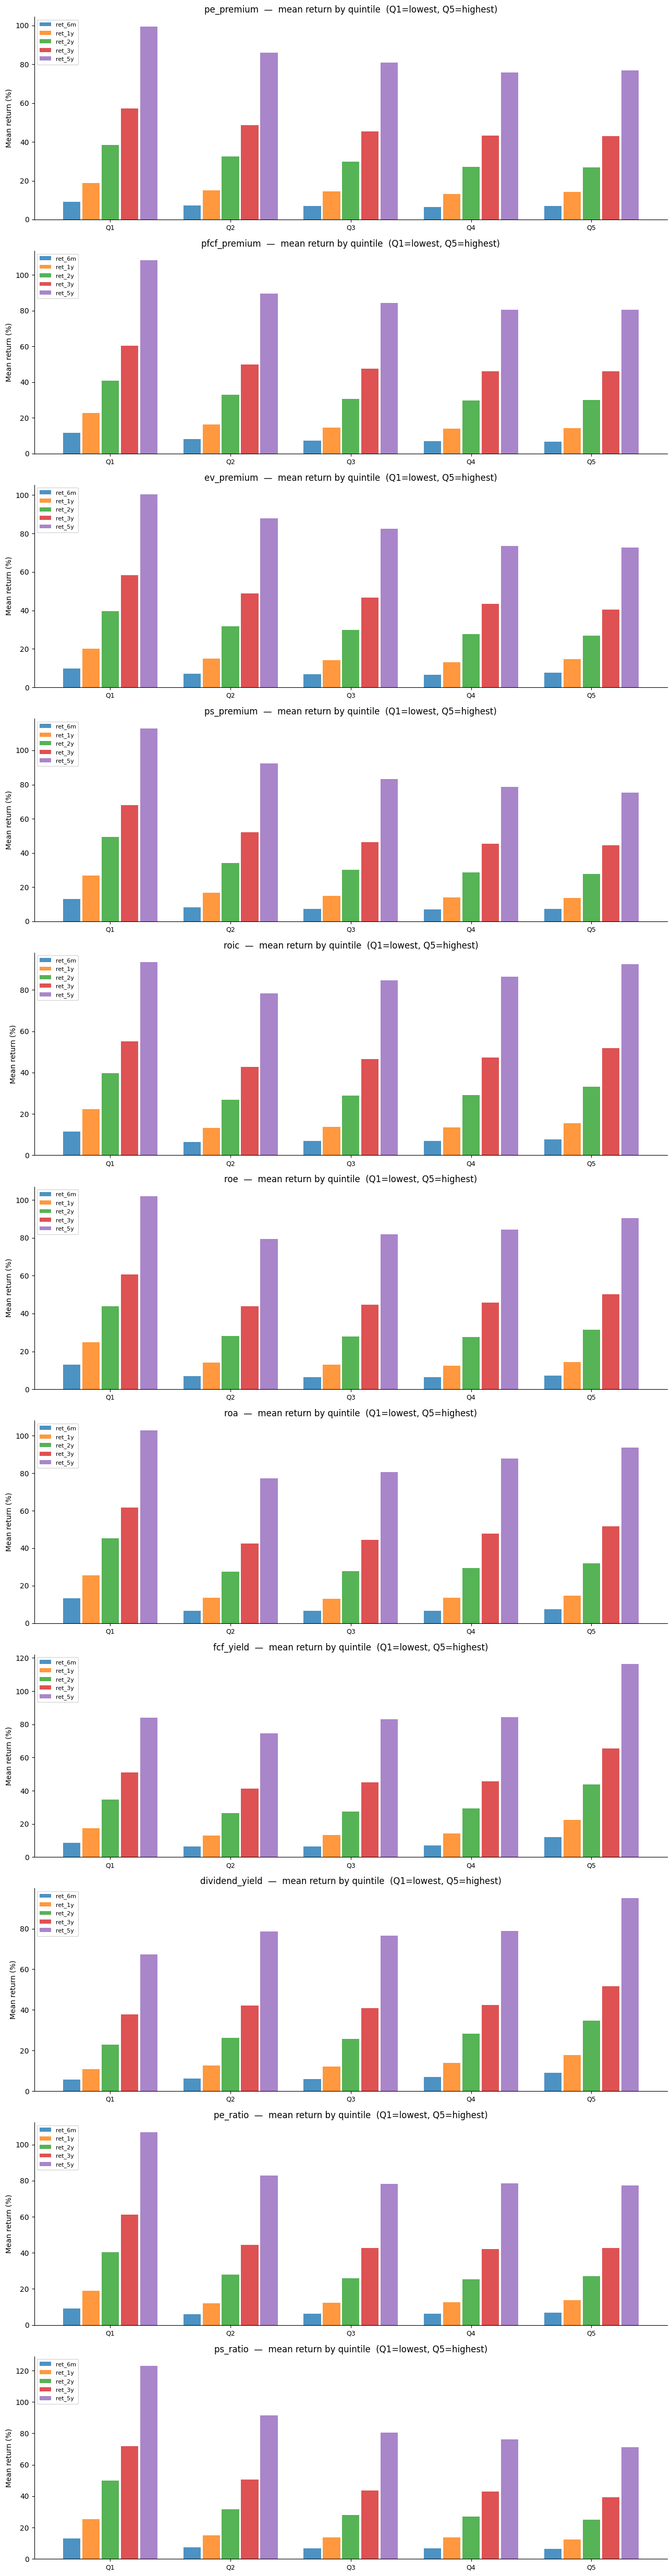

In [10]:
KEY_FEATURES = [
    'pe_premium', 'pfcf_premium', 'ev_premium', 'ps_premium',
    'roic', 'roe', 'roa',
    'fcf_yield', 'dividend_yield',
    'pe_ratio', 'ps_ratio',
]

def quintile_returns(data, feature, targets, n_bins=5):
    """Mean return by quintile for one feature across all targets."""
    rows = {}
    for target in targets:
        sub = get_valid(data, target)[[feature, target]].dropna()
        if len(sub) < 100:
            continue
        sub['bucket'] = pd.qcut(sub[feature], q=n_bins, labels=False, duplicates='drop')
        rows[target] = sub.groupby('bucket')[target].mean() * 100
    return pd.DataFrame(rows) if rows else pd.DataFrame()

n_feats   = len(KEY_FEATURES)
n_targets = len(EDA_TARGETS)
fig, axes = plt.subplots(n_feats, 1, figsize=(13, 4.5 * n_feats))
if n_feats == 1:
    axes = [axes]

colors = plt.cm.tab10.colors

for ax, feat in zip(axes, KEY_FEATURES):
    qt = quintile_returns(df, feat, EDA_TARGETS, N_BINS)
    if qt.empty:
        ax.set_title(f'{feat}  (insufficient data)')
        continue
    x = np.arange(len(qt))
    width = 0.8 / max(len(EDA_TARGETS), 1)
    for i, target in enumerate(EDA_TARGETS):
        if target not in qt.columns:
            continue
        ax.bar(x + i * width, qt[target], width=width * 0.9,
               label=target, color=colors[i % len(colors)], alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(x + width * (n_targets - 1) / 2)
    ax.set_xticklabels([f'Q{i+1}' for i in range(len(qt))], fontsize=9)
    ax.set_ylabel('Mean return (%)')
    ax.set_title(f'{feat}  —  mean return by quintile  (Q1=lowest, Q5=highest)')
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

---
## Cell 9 — ML: XGBoost Feature Importance

One XGBoost regressor per return horizon. SHAP values reveal which features drive
predictions and in which direction.

In [11]:
from xgboost import XGBRegressor
import shap
from tqdm.auto import tqdm

MIN_ROWS_TO_TRAIN = 500

def get_xgb_params(n_rows):
    """Scale regularisation with dataset size."""
    if n_rows < 2_000:
        return dict(n_estimators=100, max_depth=3, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, min_child_weight=20)
    return dict(n_estimators=400, max_depth=4, learning_rate=0.02,
                subsample=0.8, colsample_bytree=0.8, min_child_weight=20)

models     = {}   # {target: fitted XGBRegressor}
ml_datasets = {}  # {target: (X, y)}

print('Training XGBoost models...')
print(f'{"Horizon":<12} {"Rows":>8}  {"Features":>10}  Status')
print('-' * 50)

for target in tqdm(ML_TARGETS, desc="Training horizons"):
    sub = get_valid(df, target)[FEATURE_COLS + [target, 'month_end_date', 'ticker']]
    sub = sub.dropna(subset=[target])

    # Fill feature NaNs with column median (no leakage — done per-target, pre-split)
    X = sub[FEATURE_COLS].fillna(sub[FEATURE_COLS].median())
    y = sub[target]

    if len(X) < MIN_ROWS_TO_TRAIN:
        print(f'{target:<12} {len(X):>8}  skipped (< {MIN_ROWS_TO_TRAIN} rows)')
        continue

    params = get_xgb_params(len(X))
    model  = XGBRegressor(**params, random_state=RANDOM_STATE, verbosity=0)
    model.fit(X, y)

    models[target]      = model
    ml_datasets[target] = (X.values, y.values)

    # In-sample R²
    r2 = 1 - np.sum((y - model.predict(X))**2) / np.sum((y - y.mean())**2)
    print(f'{target:<12} {len(X):>8}  {len(FEATURE_COLS):>10}  R²={r2:.3f}  (in-sample)')

# Respect PRIMARY_TARGET config; fall back to first trained model if unavailable
PRIMARY_ML_TARGET = PRIMARY_TARGET if PRIMARY_TARGET in models else next(
    (t for t in ML_TARGETS if t in models), None
)
print(f'\nPrimary target for walk-forward: {PRIMARY_ML_TARGET}')

Training XGBoost models...
Horizon          Rows    Features  Status
--------------------------------------------------


Training horizons:  20%|██        | 1/5 [02:16<09:06, 136.69s/it]

ret_6m         289273          67  R²=0.127  (in-sample)


Training horizons:  40%|████      | 2/5 [04:37<06:56, 138.96s/it]

ret_1y         280797          67  R²=0.162  (in-sample)


...

ret_2y         263894          67  R²=0.197  (in-sample)


Training horizons:  80%|████████  | 4/5 [09:15<02:19, 139.97s/it]

ret_3y         247136          67  R²=0.195  (in-sample)


Training horizons: 100%|██████████| 5/5 [11:31<00:00, 138.26s/it]

ret_5y         213896          67  R²=0.226  (in-sample)

Primary target for walk-forward: ret_1y


---
## Cell 10 — SHAP Feature Importance Plots

Bar chart: which features matter most (magnitude).  
Beeswarm: direction of effect (high feature value → positive or negative return?).

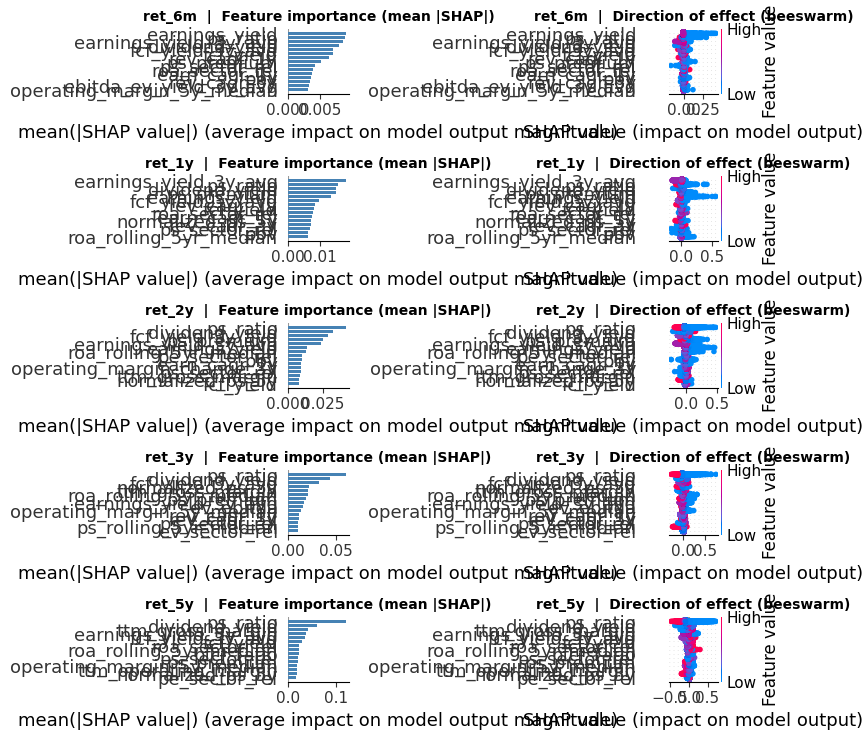


Consolidated SHAP importance across all horizons (top 15):
                            ret_6m  ret_1y  ret_2y  ret_3y  ret_5y  mean
ps_ratio                     0.009   0.016   0.042   0.060   0.122 0.050
dividend_yield               0.008   0.015   0.032   0.044   0.062 0.032
fcf_yield_3y_avg             0.007   0.010   0.029   0.032   0.035 0.023
earnings_yield_3y_avg        0.009   0.018   0.024   0.017   0.038 0.021
ps_premium                   0.005   0.015   0.025   0.019   0.021 0.017
ttm_gross_margin             0.001   0.003   0.009   0.021   0.042 0.015
roa_rolling_5yr_median       0.002   0.006   0.013   0.021   0.023 0.013
fcf_yield                    0.007   0.008   0.008   0.007   0.030 0.012
normalized_ps_5y             0.002   0.007   0.008   0.022   0.019 0.012
roa_sector_rel               0.004   0.008   0.008   0.010   0.025 0.011
earnings_yield               0.009   0.014   0.014   0.009   0.009 0.011
ps_sector_rel                0.004   0.007   0.009   0.011   0.0

In [12]:
if not models:
    print('No models trained. Run Cell 9 first.')
else:
    trained = list(models.keys())
    fig, axes = plt.subplots(len(trained), 2, figsize=(16, 5.5 * len(trained)))
    if len(trained) == 1:
        axes = [axes]

    shap_importance = {}

    for row_idx, target in enumerate(trained):
        model_t = models[target]
        X_t, y_t = ml_datasets[target]

        # Use a sample for SHAP speed on large datasets
        sample_size = min(5_000, len(X_t))
        idx = np.random.RandomState(RANDOM_STATE).choice(len(X_t), sample_size, replace=False)
        X_sample = X_t[idx]

        explainer   = shap.TreeExplainer(model_t)
        shap_values = explainer.shap_values(X_sample)

        shap_importance[target] = pd.Series(
            np.abs(shap_values).mean(axis=0),
            index=FEATURE_COLS
        ).sort_values(ascending=False)

        ax_bar = axes[row_idx][0]
        plt.sca(ax_bar)
        shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLS,
                          plot_type='bar', show=False, max_display=15, color='steelblue')
        ax_bar.set_title(f'{target}  |  Feature importance (mean |SHAP|)',
                         fontsize=10, fontweight='bold')

        ax_bee = axes[row_idx][1]
        plt.sca(ax_bee)
        shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLS,
                          show=False, max_display=15)
        ax_bee.set_title(f'{target}  |  Direction of effect (beeswarm)',
                         fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Consolidated importance table
    imp_df = pd.DataFrame(shap_importance).round(5)
    imp_df['mean'] = imp_df.mean(axis=1)
    imp_df = imp_df.sort_values('mean', ascending=False)
    print('\nConsolidated SHAP importance across all horizons (top 15):')
    print(imp_df.head(15).to_string())

---
## Cell 10b — SHAP-based Feature Pruning

Drop features whose mean |SHAP| (averaged across all trained horizons) falls below
`SHAP_PRUNE_THRESHOLD × top_feature_score`. Then retrain all models on the pruned
feature set so Cell 11 walk-forward and Cell 13 live scoring are consistent.

In [13]:
# ── Cell 10b — SHAP-based Feature Pruning ────────────────────────────────────
#
# Drop features whose mean |SHAP| (averaged across all trained horizons) is below
# SHAP_PRUNE_THRESHOLD × top-feature score. Then retrain models on the pruned set
# so Cell 11 walk-forward and Cell 13 live scoring use the same feature list.

if not shap_importance:
    print('No SHAP values. Run Cell 10 first.')
else:
    imp_mean  = pd.DataFrame(shap_importance).mean(axis=1)
    threshold = imp_mean.max() * SHAP_PRUNE_THRESHOLD

    original_count = len(FEATURE_COLS)
    FEATURE_COLS   = [f for f in FEATURE_COLS if imp_mean.get(f, 0.0) >= threshold]
    dropped        = [f for f in imp_mean.sort_values(ascending=False).index
                      if f not in FEATURE_COLS]

    print(f'Features: {original_count} → {len(FEATURE_COLS)}  '
          f'(threshold = {SHAP_PRUNE_THRESHOLD:.0%} × top feature score = {threshold:.5f})')
    if dropped:
        print(f'\nDropped ({len(dropped)}): {dropped}')

    print(f'\nKept ({len(FEATURE_COLS)}):')
    for feat, score in imp_mean[FEATURE_COLS].sort_values(ascending=False).items():
        print(f'  {feat:35}: {score:.5f}')

    # Retrain on pruned features so Cell 13 live-scoring models match FEATURE_COLS
    print('\nRetraining models on pruned features...')
    for target in list(ML_TARGETS):
        if target not in models:
            continue
        sub = get_valid(df, target)[FEATURE_COLS + [target]].dropna(subset=[target])
        X   = sub[FEATURE_COLS].fillna(sub[FEATURE_COLS].median())
        y   = sub[target]
        params = get_xgb_params(len(X))
        model  = XGBRegressor(**params, random_state=RANDOM_STATE, verbosity=0)
        model.fit(X, y)
        models[target]      = model
        ml_datasets[target] = (X.values, y.values)
        r2 = 1 - np.sum((y - model.predict(X)) ** 2) / np.sum((y - y.mean()) ** 2)
        print(f'  {target:<10} features={len(FEATURE_COLS):>3}  R²={r2:.3f}')

    print(f'\nFEATURE_COLS updated — Cells 11, 12, 13 will use {len(FEATURE_COLS)} features.')

Features: 67 → 46  (threshold = 5% × top feature score = 0.00249)

Dropped (21): ['gross_margin_slope_5y', 'roic_sector_rel', 'roe', 'pe_ratio', 'pbv_premium', 'ebitda_ev_yield', 'normalized_pe_5y', 'ebitda_ev_yield_5y_avg', 'ev_ebitda_rolling_5yr_median', 'normalized_pfcf_5y', 'fcf_margin_change_3y', 'pfcf_premium', 'ttm_fcf_margin', 'pfcf_rolling_5yr_median', 'roa_premium', 'earn_cagr_5y', 'pe_premium', 'roic', 'fcf_cagr_1y', 'fcf_cagr_5y', 'fcf_cagr_3y']

Kept (46):
  ps_ratio                           : 0.04981
  dividend_yield                     : 0.03227
  fcf_yield_3y_avg                   : 0.02263
  earnings_yield_3y_avg              : 0.02107
  ps_premium                         : 0.01704
  ttm_gross_margin                   : 0.01508
  roa_rolling_5yr_median             : 0.01306
  fcf_yield                          : 0.01205
  normalized_ps_5y                   : 0.01174
  roa_sector_rel                     : 0.01083
  earnings_yield                     : 0.01077
  ps_sect

---
## Cell 11 — Walk-Forward Validation

Proper time-series validation: train on all months up to T, predict month T+1.
Run for **1y, 2y, 3y, and 5y** horizons. Three benchmarks per horizon:
- **ML top-20%**: stocks ranked highest by model prediction
- **Universe equal-weight**: all stocks with valid data
- **SPY**: S&P 500 ETF forward return over the same horizon

In [14]:
from sklearn.metrics import r2_score as sk_r2
from tqdm.auto import tqdm

WF_HORIZONS      = [t for t in ['ret_1y', 'ret_2y', 'ret_3y', 'ret_5y'] if t in models]
MIN_TRAIN_MONTHS = 60
TOP_DECILE_PCT   = 0.20

# ── Load SPY forward returns ──────────────────────────────────────────────────
spy_fwd = {}
if PRICES_DB_PATH:
    try:
        spy_conn = duckdb.connect(PRICES_DB_PATH, read_only=True)
        spy_raw  = spy_conn.execute("""
            SELECT
                (date_trunc('month', date) + interval '1 month' - interval '1 day')::DATE
                    AS month_end_date,
                LAST(adj_close ORDER BY date) AS price
            FROM stock_prices
            WHERE ticker = 'SPY'
            GROUP BY date_trunc('month', date)
            ORDER BY month_end_date
        """).df()
        spy_conn.close()
        spy_raw['ticker']         = 'SPY'
        spy_raw['month_end_date'] = pd.to_datetime(spy_raw['month_end_date'])
        spy_df = compute_forward_returns(spy_raw, RETURN_HORIZONS)
        for col in RETURN_COLS:
            spy_fwd[col] = {
                pd.Timestamp(k): v
                for k, v in spy_df.set_index('month_end_date')[col].dropna().items()
            }
        print(f'SPY loaded: {len(spy_raw):,} months')
    except Exception as e:
        print(f'SPY benchmark unavailable: {e}')
else:
    print('PRICES_DB_PATH not set — SPY benchmark skipped')

# ── Walk-forward per horizon ──────────────────────────────────────────────────
wf_results_all = {}

for WF_TARGET in tqdm(WF_HORIZONS, desc="WF horizons", position=0):
    wf_cols     = FEATURE_COLS + [WF_TARGET, 'month_end_date', 'ticker']
    ml_dated_wf = get_valid(df, WF_TARGET)[wf_cols].copy().dropna(subset=[WF_TARGET])
    dates_sorted = sorted(ml_dated_wf['month_end_date'].unique())
    n_test = len(dates_sorted) - MIN_TRAIN_MONTHS

    print(f'\n--- {WF_TARGET}  ({len(dates_sorted)} months total, {n_test} test months) ---')
    if n_test < 12:
        print('  Insufficient test months — skipping')
        continue

    wf_results = []
    for i in tqdm(range(MIN_TRAIN_MONTHS, len(dates_sorted)), desc=f"{WF_TARGET}", leave=False, position=1):
        train_dates = dates_sorted[:i]
        test_date   = dates_sorted[i]

        train = ml_dated_wf[ml_dated_wf['month_end_date'].isin(train_dates)]
        test  = ml_dated_wf[ml_dated_wf['month_end_date'] == test_date].copy()
        if len(test) < 5:
            continue

        X_tr = train[FEATURE_COLS].fillna(train[FEATURE_COLS].median())
        y_tr = train[WF_TARGET]
        X_te = test[FEATURE_COLS].fillna(train[FEATURE_COLS].median())
        y_te = test[WF_TARGET]

        params   = {**get_xgb_params(len(X_tr)), 'n_estimators': 100, 'n_jobs': -1, 'tree_method': 'hist'}
        wf_model = XGBRegressor(**params, random_state=RANDOM_STATE, verbosity=0)
        wf_model.fit(X_tr, y_tr)

        preds        = wf_model.predict(X_te)
        test         = test.copy()
        test['pred'] = preds

        n_top     = max(1, int(len(test) * TOP_DECILE_PCT))
        top_ret   = test.nlargest(n_top, 'pred')[WF_TARGET].mean()
        bench_ret = y_te.mean()
        spy_ret   = spy_fwd.get(WF_TARGET, {}).get(pd.Timestamp(test_date), np.nan)
        ic, _     = spearmanr(preds, y_te)

        wf_results.append({
            'month':              test_date,
            'train_months':       i,
            'n_stocks':           len(test),
            'top_ret':            top_ret,
            'bench_ret':          bench_ret,
            'spy_ret':            spy_ret,
            'excess_vs_universe': top_ret - bench_ret,
            'excess_vs_spy':      top_ret - spy_ret if not np.isnan(spy_ret) else np.nan,
            'monthly_ic':         ic,
        })

    wf_df = pd.DataFrame(wf_results)
    wf_results_all[WF_TARGET] = wf_df

    spy_mean = wf_df['spy_ret'].mean()
    ex_spy   = wf_df['excess_vs_spy'].mean()
    icir     = wf_df['monthly_ic'].mean() / wf_df['monthly_ic'].std()
    win_rate = (wf_df['excess_vs_universe'] > 0).mean()

    print(f'  ML top-{TOP_DECILE_PCT:.0%}          : {wf_df["top_ret"].mean()*100:+.2f}%')
    print(f'  Universe EW           : {wf_df["bench_ret"].mean()*100:+.2f}%')
    if not np.isnan(spy_mean):
        print(f'  SPY                   : {spy_mean*100:+.2f}%')
    print(f'  Excess vs universe    : {wf_df["excess_vs_universe"].mean()*100:+.2f}%')
    if not np.isnan(ex_spy):
        print(f'  Excess vs SPY         : {ex_spy*100:+.2f}%')
    print(f'  Win rate vs universe  : {win_rate:.0%}')
    print(f'  Mean IC               : {wf_df["monthly_ic"].mean():.4f}')
    print(f'  ICIR                  : {icir:.3f}')

# Keep ml_dated / wf_df / WF_TARGET defined for Cells 12 and 13
WF_TARGET = PRIMARY_ML_TARGET
wf_df     = wf_results_all.get(PRIMARY_ML_TARGET, pd.DataFrame())
ml_dated  = (get_valid(df, PRIMARY_ML_TARGET)
             [FEATURE_COLS + [PRIMARY_ML_TARGET, 'month_end_date', 'ticker']]
             .copy()
             .dropna(subset=[PRIMARY_ML_TARGET]))

  ret_6m: 314 valid  mean=4.6%  median=5.9%
  ret_1y: 308 valid  mean=9.6%  median=13.0%
  ret_2y: 296 valid  mean=20.7%  median=23.3%
  ret_3y: 284 valid  mean=32.7%  median=38.1%
  ret_5y: 260 valid  mean=62.1%  median=70.2%
SPY loaded: 319 months


WF horizons:   0%|          | 0/4 [00:00<?, ?it/s]


--- ret_1y  (307 months total, 247 test months) ---


WF horizons:  25%|██▌       | 1/4 [03:46<11:18, 226.18s/it]

  ML top-20%          : +31.18%
  Universe EW           : +16.91%
  SPY                   : +12.15%
  Excess vs universe    : +14.27%
  Excess vs SPY         : +19.03%
  Win rate vs universe  : 97%
  Mean IC               : 0.1401
  ICIR                  : 0.989

--- ret_2y  (295 months total, 235 test months) ---


...

  ML top-20%          : +57.39%
  Universe EW           : +31.91%
  SPY                   : +24.95%
  Excess vs universe    : +25.47%
  Excess vs SPY         : +32.43%
  Win rate vs universe  : 100%
  Mean IC               : 0.2088
  ICIR                  : 1.707

--- ret_3y  (283 months total, 223 test months) ---


WF horizons:  75%|███████▌  | 3/4 [10:41<03:28, 208.84s/it]

  ML top-20%          : +80.09%
  Universe EW           : +45.62%
  SPY                   : +38.01%
  Excess vs universe    : +34.47%
  Excess vs SPY         : +42.08%
  Win rate vs universe  : 98%
  Mean IC               : 0.2387
  ICIR                  : 2.520

--- ret_5y  (259 months total, 199 test months) ---


WF horizons: 100%|██████████| 4/4 [13:31<00:00, 202.89s/it]

  ML top-20%          : +137.38%
  Universe EW           : +85.64%
  SPY                   : +76.75%
  Excess vs universe    : +51.74%
  Excess vs SPY         : +60.63%
  Win rate vs universe  : 99%
  Mean IC               : 0.3063
  ICIR                  : 2.720


---
## Cell 12 — Walk-Forward: Cumulative Return Charts

One row per horizon. Left: cumulative return (ML top-20% vs Universe EW vs SPY).
Right: monthly IC bar chart.

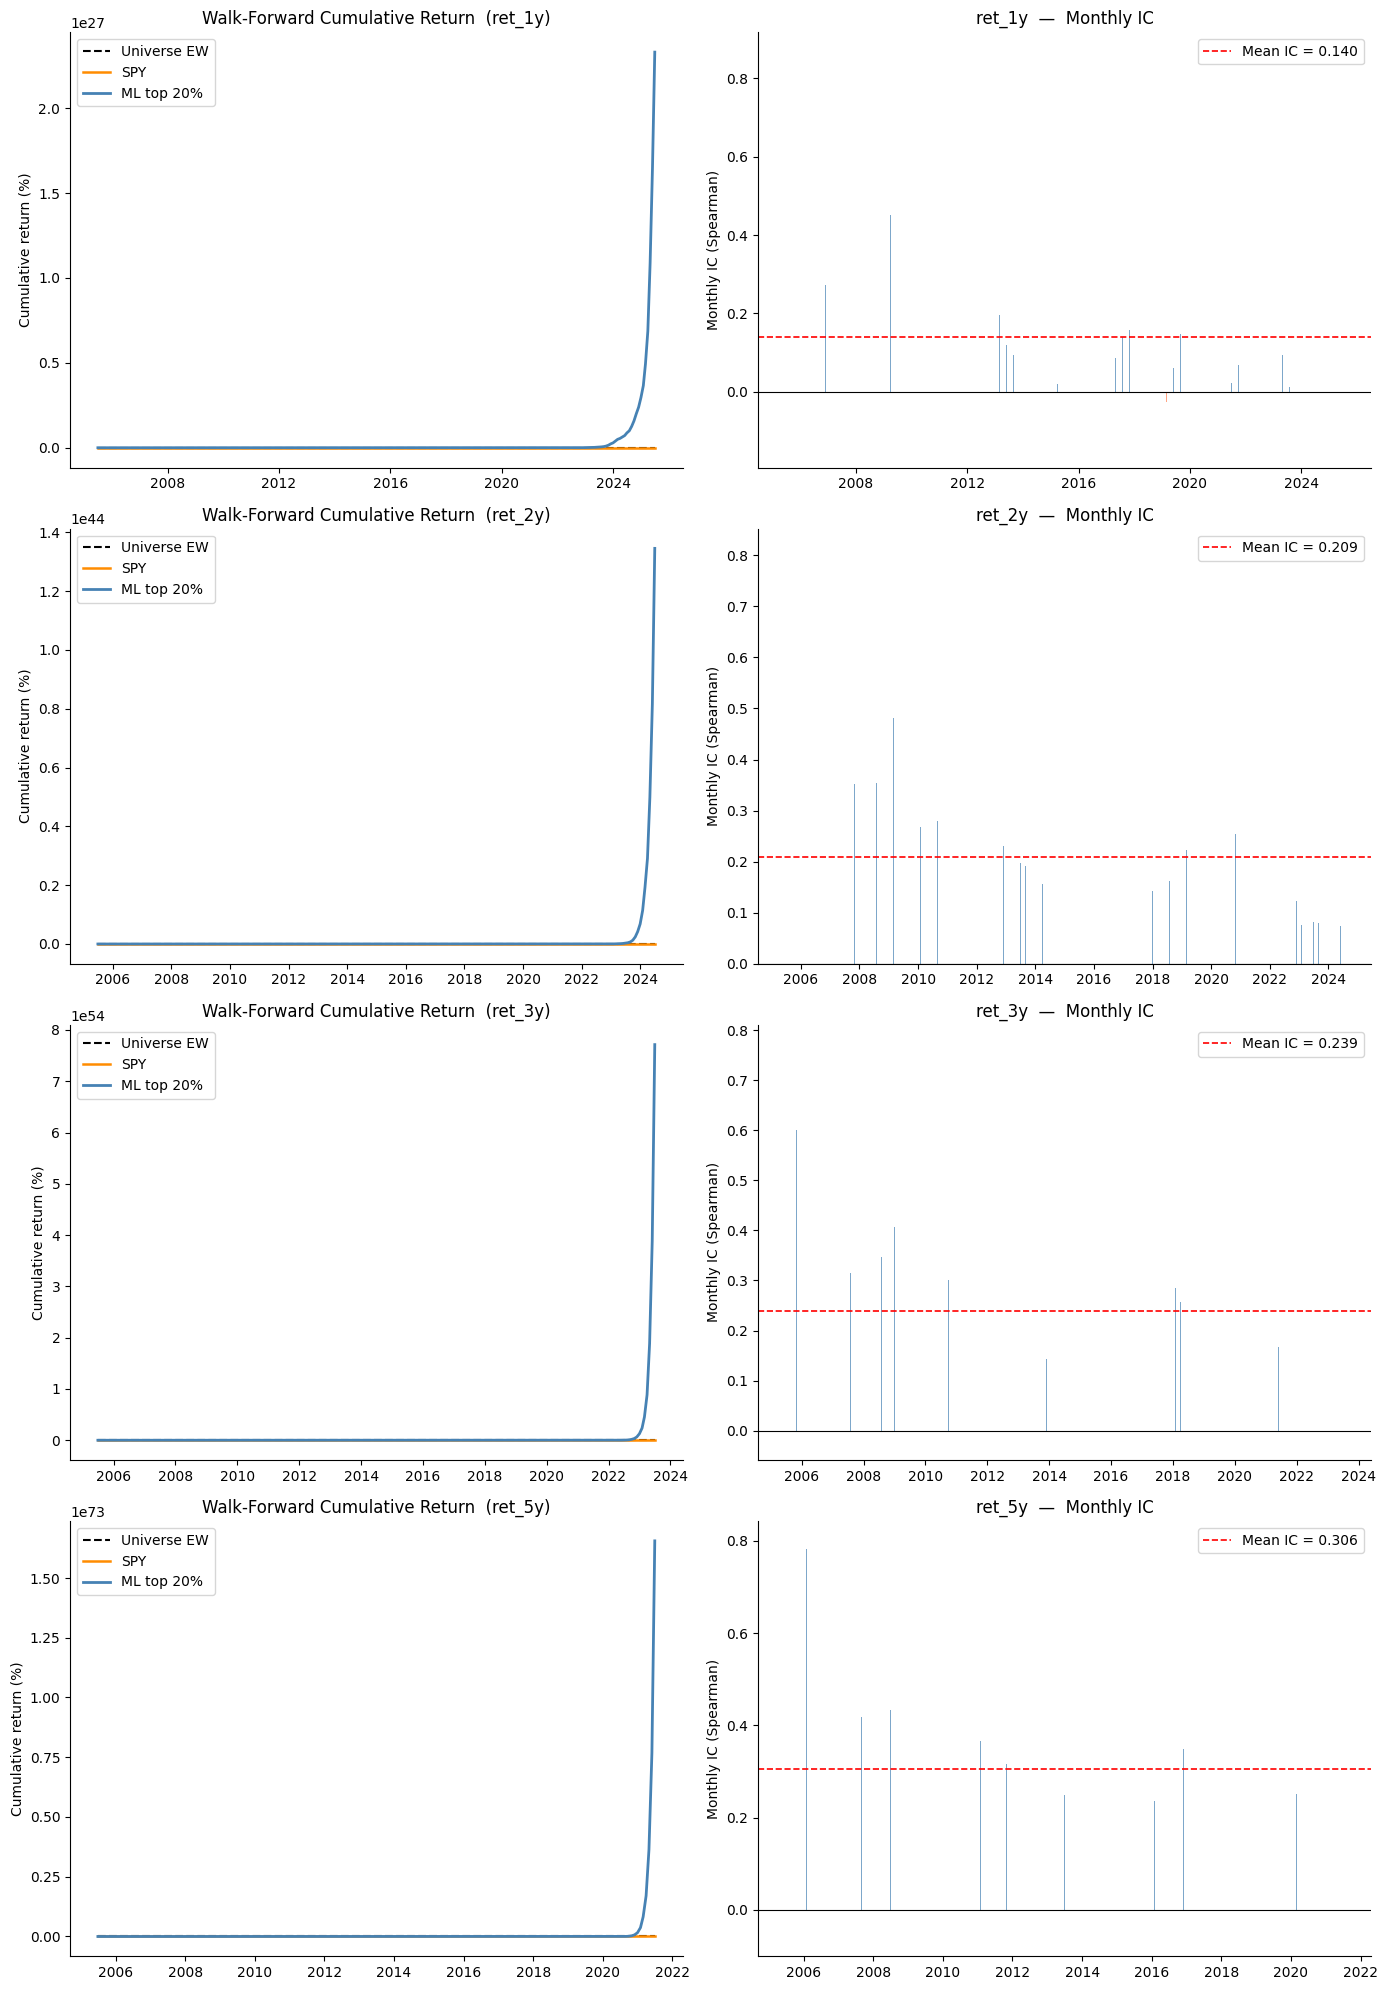

In [15]:
if not wf_results_all:
    print('No walk-forward results. Run Cell 11 first.')
else:
    targets = list(wf_results_all.keys())
    n = len(targets)
    fig, axes = plt.subplots(n, 2, figsize=(14, 5 * n))
    if n == 1:
        axes = [axes]

    for row_idx, target in enumerate(targets):
        wf        = wf_results_all[target]
        wf_idx    = wf.set_index('month')
        cum_top   = (1 + wf_idx['top_ret']).cumprod() - 1
        cum_bench = (1 + wf_idx['bench_ret']).cumprod() - 1
        spy_s     = wf_idx['spy_ret'].dropna()
        cum_spy   = (1 + spy_s).cumprod() - 1

        ax1 = axes[row_idx][0]
        ax1.plot(cum_bench.index, cum_bench * 100, 'k--',         lw=1.5, label='Universe EW')
        if not cum_spy.empty:
            ax1.plot(cum_spy.index, cum_spy * 100, color='darkorange', lw=1.8, label='SPY')
        ax1.plot(cum_top.index, cum_top * 100, color='steelblue', lw=2,
                 label=f'ML top {TOP_DECILE_PCT:.0%}')
        ax1.set_ylabel('Cumulative return (%)')
        ax1.set_title(f'Walk-Forward Cumulative Return  ({target})')
        ax1.legend()

        ax2 = axes[row_idx][1]
        ax2.bar(wf['month'], wf['monthly_ic'],
                color=np.where(wf['monthly_ic'] >= 0, 'steelblue', 'coral'),
                alpha=0.7)
        ax2.axhline(0, color='black', lw=0.8)
        mean_ic = wf['monthly_ic'].mean()
        ax2.axhline(mean_ic, color='red', lw=1.2, linestyle='--',
                    label=f'Mean IC = {mean_ic:.3f}')
        ax2.set_ylabel('Monthly IC (Spearman)')
        ax2.set_title(f'{target}  —  Monthly IC')
        ax2.legend()

    plt.tight_layout()
    plt.show()

---
## Cell 13 — Live Scoring: Rank All Current Tickers

Apply the trained model to today's fundamentals from `pe_stats`.
Output: ranked list of tickers by predicted forward return.

In [16]:
if PRIMARY_ML_TARGET not in models:
    print(f"No model for {PRIMARY_ML_TARGET}. Run Cell 9 first.")
else:
    live = get_pe_stats()
    print(f"Tickers in pe_stats: {len(live):,}")

    def _col(name):
        return live[name] if name in live.columns else pd.Series(np.nan, index=live.index)

    fdf = pd.DataFrame(index=live.index)
    # Valuation multiples
    fdf["pe_ratio"]                     = _col("current_pe")
    fdf["pfcf_ratio"]                   = _col("current_pfcf")
    fdf["ev_ebitda"]                    = _col("current_evebitda")
    fdf["ps_ratio"]                     = _col("current_ps")
    fdf["pbv"]                          = _col("current_pbv")
    fdf["ptbv"]                         = _col("current_ptbv")
    fdf["fcf_yield"]                    = _col("current_fcf_yield")
    fdf["dividend_yield"]               = _col("dividend_yield")
    # Yield metrics
    fdf["earnings_yield"]               = _col("current_earnings_yield")
    fdf["earnings_yield_3y_avg"]        = _col("earnings_yield_3y_avg")
    fdf["earnings_yield_5y_avg"]        = _col("earnings_yield_5y_avg")
    fdf["fcf_yield_3y_avg"]             = _col("fcf_yield_3y_avg")
    fdf["fcf_yield_5y_avg"]             = _col("fcf_yield_5y_avg")
    fdf["ebitda_ev_yield"]              = _col("current_ebitda_ev_yield")
    fdf["ebitda_ev_yield_3y_avg"]       = _col("ebitda_ev_yield_3y_avg")
    fdf["ebitda_ev_yield_5y_avg"]       = _col("ebitda_ev_yield_5y_avg")
    # Normalized multiples
    fdf["normalized_pe_5y"]             = _col("normalized_pe_5y")
    fdf["normalized_pfcf_5y"]           = _col("normalized_pfcf_5y")
    fdf["normalized_evebitda_5y"]       = _col("normalized_evebitda_5y")
    fdf["normalized_ps_5y"]             = _col("normalized_ps_5y")
    # Quality
    fdf["roa"]                          = _col("current_roa")
    fdf["roe"]                          = _col("current_roe")
    fdf["roic"]                         = _col("current_roic")
    # Rolling medians
    fdf["pe_rolling_5yr_median"]        = _col("pe_rolling_5yr_median")
    fdf["pfcf_rolling_5yr_median"]      = _col("pfcf_rolling_5yr_median")
    fdf["ev_ebitda_rolling_5yr_median"] = _col("evebitda_rolling_5yr_median")
    fdf["ps_rolling_5yr_median"]        = _col("ps_rolling_5yr_median")
    fdf["roa_rolling_5yr_median"]       = _col("roa_rolling_5yr_median")
    fdf["roe_rolling_5yr_median"]       = _col("roe_rolling_5yr_median")
    fdf["roic_rolling_5yr_median"]      = _col("roic_rolling_5yr_median")
    fdf["pbv_rolling_5yr_median"]       = _col("pbv_rolling_5yr_median")
    fdf["ptbv_rolling_5yr_median"]      = _col("ptbv_rolling_5yr_median")
    # Growth: pe_stats uses _yr suffix; training data uses _y
    fdf["rev_cagr_1y"]  = _col("rev_growth_1yr")
    fdf["rev_cagr_3y"]  = _col("rev_cagr_3yr")
    fdf["rev_cagr_5y"]  = _col("rev_cagr_5yr")
    fdf["earn_cagr_1y"] = _col("earn_growth_1yr")
    fdf["earn_cagr_3y"] = _col("earn_cagr_3yr")
    fdf["earn_cagr_5y"] = _col("earn_cagr_5yr")
    fdf["fcf_cagr_1y"]  = _col("fcf_growth_1yr")
    fdf["fcf_cagr_3y"]  = _col("fcf_cagr_3yr")
    fdf["fcf_cagr_5y"]  = _col("fcf_cagr_5yr")
    # Margins and leverage (direct column name match)
    for col in ["current_gross_margin", "gross_margin_5y_median", "gross_margin_slope_5y",
                "current_operating_margin", "operating_margin_5y_median",
                "operating_margin_change_3y", "operating_margin_slope_5y",
                "current_fcf_margin", "fcf_margin_5y_median", "fcf_margin_change_3y",
                "roa_stability_5y", "debt_to_ebitda", "interest_coverage"]:
        feat = col.replace("current_", "ttm_").replace("_margin", "_margin") if col.startswith("current_") else col
        # Map pe_stats name to FEATURE_COLS name
        _MAP = {
            "current_gross_margin":    "ttm_gross_margin",
            "current_operating_margin":"ttm_operating_margin",
            "current_fcf_margin":      "ttm_fcf_margin",
        }
        fdf[_MAP.get(col, col)] = _col(col)

    # ── Mean-reversion premiums ───────────────────────────────────────────────
    fdf["pe_premium"]   = safe_ratio(fdf["pe_ratio"],   fdf["pe_rolling_5yr_median"])
    fdf["pfcf_premium"] = safe_ratio(fdf["pfcf_ratio"], fdf["pfcf_rolling_5yr_median"])
    fdf["ev_premium"]   = safe_ratio(fdf["ev_ebitda"],  fdf["ev_ebitda_rolling_5yr_median"])
    fdf["ps_premium"]   = safe_ratio(fdf["ps_ratio"],   fdf["ps_rolling_5yr_median"])
    fdf["roa_premium"]  = safe_ratio(fdf["roa"],        fdf["roa_rolling_5yr_median"])
    fdf["roe_premium"]  = safe_ratio(fdf["roe"],        fdf["roe_rolling_5yr_median"])
    fdf["roic_premium"] = safe_ratio(fdf["roic"],       fdf["roic_rolling_5yr_median"])
    fdf["pbv_premium"]  = safe_ratio(fdf["pbv"],        fdf["pbv_rolling_5yr_median"])
    fdf["ptbv_premium"] = safe_ratio(fdf["ptbv"],       fdf["ptbv_rolling_5yr_median"])

    # ── Sector-relative features ──────────────────────────────────────────────
    _LIVE_SEC_REL = [
        ("current_pe",       True,  "pe_sector_rel"),
        ("current_pfcf",     True,  "pfcf_sector_rel"),
        ("current_evebitda", True,  "ev_sector_rel"),
        ("current_ps",       True,  "ps_sector_rel"),
        ("current_roic",     False, "roic_sector_rel"),
        ("current_roa",      False, "roa_sector_rel"),
    ]
    if "sector" in live.columns and live["sector"].notna().any():
        for src_col, positive_only, out_col in _LIVE_SEC_REL:
            if out_col not in FEATURE_COLS:
                continue
            if src_col not in live.columns:
                fdf[out_col] = np.nan
                continue
            tmp = live[["sector", src_col]].copy()
            mask = tmp["sector"].notna() & tmp[src_col].notna()
            if positive_only:
                mask = mask & (tmp[src_col] > 0)
            med = tmp[mask].groupby("sector")[src_col].median().rename("_med")
            tmp = tmp.join(med, on="sector")
            fdf[out_col] = safe_ratio(
                pd.Series(tmp[src_col].values, index=fdf.index),
                pd.Series(tmp["_med"].values,  index=fdf.index),
            )
    else:
        for _, _, out_col in _LIVE_SEC_REL:
            if out_col in FEATURE_COLS:
                fdf[out_col] = np.nan

    train_medians = ml_dated[FEATURE_COLS].median()
    X_live = fdf[FEATURE_COLS].copy()
    for col in FEATURE_COLS:
        X_live[col] = X_live[col].fillna(train_medians.get(col, 0))

    live["pred_ret"] = models[PRIMARY_ML_TARGET].predict(X_live.values)
    live["ml_rank"]  = live["pred_ret"].rank(ascending=False).astype(int)

    display_cols = [
        "ticker", "ml_rank", "sector", "current_price", "pred_ret",
        "market_cap_b", "forward_pe", "current_roic", "current_ps", "sector_val_score",
        "current_gross_margin", "current_operating_margin", "debt_to_ebitda",
    ]
    top50 = live.nsmallest(50, "ml_rank")[
        [c for c in display_cols if c in live.columns]
    ].copy()
    top50["pred_ret_pct"] = (top50["pred_ret"] * 100).round(1)
    top50 = top50.drop(columns="pred_ret")

    print(f"\nTop 50 by predicted {PRIMARY_ML_TARGET} return:")
    print(top50.round(2).to_string(index=False))

SyntaxError: unterminated f-string literal (detected at line 134) (3363226257.py, line 134)

---
## Cell 14 — Summary

In [ ]:
print('=' * 70)
print('  FUNDAMENTALS ALPHA — SUMMARY')
print('=' * 70)
print(f'  Data:           {len(df):,} monthly observations, {df["ticker"].nunique():,} tickers')
print(f'  Date range:     {df["month_end_date"].min().date()} → {df["month_end_date"].max().date()}')
print(f'  Features:       {len(FEATURE_COLS)}')
print(f'  Primary target: {PRIMARY_ML_TARGET}')
print()

if models:
    print('── MODELS TRAINED ────────────────────────────────────────────────────')
    for target in ML_TARGETS:
        if target in models:
            X_t, y_t = ml_datasets[target]
            preds = models[target].predict(X_t)
            r2 = 1 - np.sum((y_t - preds)**2) / np.sum((y_t - y_t.mean())**2)
            print(f'  {target:<10} rows={len(X_t):>7,}  in-sample R²={r2:.3f}')

if wf_results_all:
    print()
    print('── WALK-FORWARD RESULTS ──────────────────────────────────────────────')
    rows = []
    for target, wf in wf_results_all.items():
        icir     = wf['monthly_ic'].mean() / wf['monthly_ic'].std()
        spy_mean = wf['spy_ret'].mean()
        ex_spy   = wf['excess_vs_spy'].mean()
        rows.append({
            'horizon':   target,
            'months':    len(wf),
            'ml_top%':   f"{wf['top_ret'].mean()*100:+.2f}%",
            'univ_ew':   f"{wf['bench_ret'].mean()*100:+.2f}%",
            'spy':       f"{spy_mean*100:+.2f}%" if not np.isnan(spy_mean) else 'N/A',
            'vs_univ':   f"{wf['excess_vs_universe'].mean()*100:+.2f}%",
            'vs_spy':    f"{ex_spy*100:+.2f}%" if not np.isnan(ex_spy) else 'N/A',
            'win_rate':  f"{(wf['excess_vs_universe'] > 0).mean():.0%}",
            'mean_ic':   f"{wf['monthly_ic'].mean():.4f}",
            'icir':      f"{icir:.3f}",
        })
    print(pd.DataFrame(rows).set_index('horizon').to_string())

print()
print('To interpret results:')
print('  - Negative IC for PE/PS/EV premiums = cheaper stocks outperform (value factor)')
print('  - Positive IC for ROIC/ROE = higher quality outperforms (quality factor)')
print('  - ICIR > 0.5 = practically significant factor')
print('  - ICIR > 1.0 = strong, consistent factor worth trading')

  FUNDAMENTALS ALPHA — SUMMARY
  Data:           296,348 monthly observations, 1,414 tickers
  Date range:     1999-12-31 → 2026-05-31
  Features:       35
  Primary target: ret_1y

── MODELS TRAINED ────────────────────────────────────────────────────
  ret_6m     rows=289,273  in-sample R²=0.120
  ret_1y     rows=280,797  in-sample R²=0.154
  ret_2y     rows=263,894  in-sample R²=0.183
  ret_3y     rows=247,136  in-sample R²=0.175
  ret_5y     rows=213,896  in-sample R²=0.200

── WALK-FORWARD RESULTS ──────────────────────────────────────────────
         months   ml_top%  univ_ew      spy  vs_univ   vs_spy win_rate mean_ic   icir
horizon                                                                              
ret_1y      241   +33.55%  +16.91%  +12.15%  +16.64%  +21.40%      99%  0.1840  1.221
ret_2y      229   +61.67%  +31.91%  +24.95%  +29.76%  +36.72%     100%  0.2620  2.102
ret_3y      217   +87.01%  +45.62%  +38.01%  +41.39%  +49.00%      99%  0.3098  2.912
ret_5y      193